In [ ]:
""" 
Particle in quartic potential classical evolution
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================================
# --- Constants & Physical Parameters ---
# =====================================================================
m = 3e-18               # Mass of the particle (in kg)
omega = 2 * np.pi * 170e3  # Angular frequency (in rad/s), based on 170 kHz
beta = 0.001            # Strength coefficient for x^4 potential term

# --- Time Boundaries (in Seconds) ---
T_start = -1e-6         # Start time of simulation 
T_0 = 0                 # Start of phase 1
T_tau = 5e-6            # Duration of phase 1
T_end = 5e-6            # End time of simulation 

# --- Initial Ensemble Setup ---
N = int(1e4)            # Number of particles in the Monte Carlo ensemble (10,000)
sigmax = np.sqrt(0.5)   # Standard deviation of initial position distribution
sigmap = np.sqrt(0.5)   # Standard deviation of initial momentum distribution

# Sample initial positions and momenta from standard normal distributions
x0 = np.random.normal(0, sigmax, N)
p0 = np.random.normal(0, sigmap, N)

# Concatenate into a single flat vector of length 2N for the ODE solver:
# [x_1, x_2, ..., x_N, p_1, p_2, ..., p_N]
init_state = np.concatenate([x0, p0])


# =====================================================================
# --- Equations of Motion (ODE System) ---
# =====================================================================
def derivatives(t, state):
    """
    Calculates the time derivatives for the ensemble in dimensionless units.
    
    t     : Scaled time (t_scaled = T * omega)
    state : Vector containing [x_vector, p_vector]
    """
    x = state[:N]       # Extract positions for all N particles
    p = state[N:]       # Extract momenta for all N particles
    
    # dx/dt = p (Dimensionless Hamilton's equation for position)
    x_dot = p           
    
    # dp/dt = -dV/dx (Hamilton's equation for momentum)
    # The potential switches conditionally based on the scaled interaction window
    if (T_0 * omega) < t < (T_tau * omega):
        # Non-linear quartic regime: V(x) = beta * x^4 -> dV/dx = 4 * beta * x^3
        p_dot = -4 * beta * x**3
    else:
        # Standard harmonic oscillator regime: V(x) = 0.5 * x^2 -> dV/dx = x
        p_dot = -x
        
    return np.concatenate([x_dot, p_dot])


# =====================================================================
# --- Numerical Integration ---
# =====================================================================
# Convert physical time boundaries into dimensionless scaled time variables
t_start_scaled = T_start * omega
t_end_scaled = T_end * omega

# Define 200 evenly spaced time steps to evaluate and save the results
t_eval_scaled = np.linspace(t_start_scaled, t_end_scaled, 200)

print("Solving ...")
# Solve the system of 2N coupled ordinary differential equations
sol = solve_ivp(
    fun=derivatives,
    t_span=(t_start_scaled, t_end_scaled),
    y0=init_state,
    t_eval=t_eval_scaled,
    rtol=1e-8,       # Relative error tolerance
    atol=1e-10       # Absolute error tolerance
)
print("Done!")

# Reshape output matrix to shape (time_steps, particles)
# sol.y shape is (2N, 200) -> Transposed to (200, 2N) for easier time indexing
xs_all = sol.y[:N, :].T   # Extracted position history for all particles
ps_all = sol.y[N:, :].T   # Extracted momentum history for all particles


# =====================================================================
# --- Visualization (Phase-Space Snapshots) ---
# =====================================================================
# Specific physical times (in seconds) to plot snapshots for
snap_times = [T_0, (T_0 + T_tau) / 5, T_end]
nbins = 60              # Resolution grid size for the 2D density histogram
max_range = 6.5         # Symmetric boundary limit for both x and p axes [-6.5, 6.5]

# Initialize a side-by-side subplot figure layout
fig, axes = plt.subplots(1, len(snap_times), figsize=(5 * len(snap_times), 5))

for ax, times in zip(axes, snap_times):
    # Scale target snapshot time to match the solver's dimensionless timeline
    times_scaled = times * omega
    
    # Find the index in our evaluated time array closest to the target snapshot time
    time_index = np.argmin(np.abs(t_eval_scaled - times_scaled))

    # Pull the specific x and p coordinates for all particles at this point in time
    x_data = xs_all[time_index, :]
    p_data = ps_all[time_index, :]

    # Calculate 2D histogram to map the density of particles across phase-space
    # Explicitly force fixed bounding limits so densities align perfectly across plots
    counts, xedges, yedges = np.histogram2d(
        x_data, p_data, 
        bins=nbins, 
        range=[[-max_range, max_range], [-max_range, max_range]]
    )
    
    # Calculate bin centers from edges to pass into the contour plotting function
    xcenters = (xedges[:-1] + xedges[1:]) / 2
    ycenters = (yedges[:-1] + yedges[1:]) / 2

    # Draw filled density contours (using the transposed counts grid to match x,y orientation)
    cf = ax.contourf(xcenters, ycenters, counts.T, levels=20, cmap='viridis')
    
    # Add an independent colorbar matching the size and scale of each subplot
    fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    
    # Visual layout tuning: Maintain uniform, rigid 1:1 aspect square frames
    ax.set_aspect('equal')
    ax.set_xlim(-max_range, max_range)
    ax.set_ylim(-max_range, max_range)
    
    # Labels and Titles
    ax.set_xlabel('x')
    ax.set_ylabel('p')
    ax.set_title(f't = {times*1e6:.2f} μs')

# Set global figure adjustments and export the visualization
plt.suptitle('Classical phase-space evolution under x⁴', fontsize=13, y=0.98)
plt.tight_layout()
plt.savefig('wigner_snapshots_classical.png', dpi=500)
plt.show()

In [ ]:
""" 
Image of the three phases to indicate how the protocol works
"""
import matplotlib.pyplot as plt

# Setup the figure and axes
fig, ax = plt.subplots(figsize=(11, 4))

# Define arbitrary boundaries for clean proportions
t_start = -2.0
t0 = 0.0
t1 = 4.0
t2 = 6.0
t_end = 10.0

# Colored background spans (Bands)
# Before t=0: x^2 potential (using soft orange)
ax.axvspan(t_start, t0, color="#ffeeda", alpha=1.0)
# Phase 1: 0 to tau_1 (x^4, soft blue)
ax.axvspan(t0, t1, color="#f0f4f8", alpha=1.0)
# Phase 2: tau_1 to tau_2 (x^2, soft orange)
ax.axvspan(t1, t2, color="#ffeeda", alpha=1.0)
# Phase 3: after tau_2 (x^4, soft green)
ax.axvspan(t2, t_end, color="#f1f6f4", alpha=1.0)

# Vertical dashed separators at transitions
ax.axvline(t0, color="#666666", linestyle="dashed", linewidth=1.2)
ax.axvline(t1, color="#5b84b1", linestyle="dashed", linewidth=1.2)
ax.axvline(t2, color="#e09f53", linestyle="dashed", linewidth=1.2)

# Central height for text labels
y_text = 0.5

# Add text labels inside each phase zone
ax.text((t_start + t0)/2, y_text, "$x^2$", color="#ff9100", fontsize=14, ha="center", va="center", weight="bold")
ax.text((t0 + t1)/2, y_text, "Phase 1\n($x^4$)", color="#4a7c59", fontsize=13, ha="center", va="center", weight="bold") # adjusted colors for readability
ax.text((t1 + t2)/2, y_text, "Phase 2\n($x^2$)", color="#ff9100", fontsize=13, ha="center", va="center", weight="bold")
ax.text((t2 + t_end)/2, y_text, "Phase 3\n($x^4$)", color="#3b7a57", fontsize=13, ha="center", va="center", weight="bold")

# Customize axes according to instructions
ax.set_xlim(t_start, t_end)
ax.set_ylim(0, 1.0)

# Remove y-axis values and text completely
ax.set_yticks([])
ax.set_ylabel("")

# Set x-axis ticks to show only symbols: 0, \tau_1, \tau_2
ax.set_xticks([t0, t1, t2])
ax.set_xticklabels(["0", r"$\tau_1$", r"$\tau_1$ + $\tau_2$"], fontsize=14)
ax.set_xlabel("Time", fontsize=14, labelpad=10)

# Add a clean title
ax.set_title("Protocol Phase Diagram", fontsize=14, pad=15, weight="bold")

# Grid lines matching the ticks
ax.grid(True, color="#d3d3d3", linestyle="-", linewidth=0.5, axis='x')

plt.tight_layout()
plt.savefig("phase_diagram_updated.png", dpi=300)
print("Successfully saved image")

In [ ]:
"""
Sweep over tau_1 and tau_2 to find optimal protocol in terms of maximising Wigner negativity 
"""
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# ── Parameters & Operator Definitions ────────────────────────────────────────
m = 3e-18               # Mass of the particle (in kg)
omega = 2 * np.pi * 170e3  # Angular frequency (in rad/s), based on 170 kHz
alpha = 0.5                 # strength coeffcient for x^2 potential term
beta  = 0.001               # Strength coefficient for x^4 potential term
N     = 120              # Hilbert space truncation size (number of Fock states)

# Define standard quantum harmonic oscillator operators
a      = qt.destroy(N)
x      = (a + a.dag()) / np.sqrt(2)         # Dimensionless position operator
p      = 1j * (a.dag() - a) / np.sqrt(2)    # Dimensionless momentum operator

# Hamiltonians representing the two physical regimes
H_harmonic = 0.5 * p * p + alpha * x**2     # Linear/harmonic potential phase
H_quartic  = 0.5 * p * p + beta  * x**4     # Non-linear quartic interaction phase

psi_0 = qt.basis(N,0)                       # Initial state: Ground state |0⟩


# ── Helper Functions for Metrics & Dynamics ──────────────────────────────────
xvec = np.linspace(-8, 8, 200)  # Spatial coordinate grid for Wigner evaluation

def wigner_neg_volume(state):
    """Calculates the volume of the negative parts of the Wigner function."""
    W  = qt.wigner(state, xvec, xvec)
    dx = xvec[1] - xvec[0]
    # Integrates only the negative values: 0.5 * (|W| - W) extracts where W < 0
    return 0.5 * np.sum(np.abs(W) - W) * dx**2

def max_neg_volume(states, coarse_step=5):
    """Optimized two-step grid search to locate peak negativity across a state list."""
    coarse_neg = np.zeros(len(states))
    # Step 1: Coarse sweep to find approximate peak region
    for idx in range(0, len(states), coarse_step):
        coarse_neg[idx] = wigner_neg_volume(states[idx])
    
    peak = np.argmax(coarse_neg)
    refine_start = max(0, peak - coarse_step)
    refine_end   = min(len(states), peak + coarse_step + 1)
    
    # Step 2: Fine-grained sweep around the identified maximum
    for idx in range(refine_start, refine_end):
        coarse_neg[idx] = wigner_neg_volume(states[idx])
    
    best_idx = np.argmax(coarse_neg)
    return np.max(coarse_neg), best_idx   

def evolve(H, psi_in, duration_dimless, n_steps=300):
    """Evolves state under H and returns the entire state trajectory."""
    t = np.linspace(0, duration_dimless, n_steps)
    result = qt.sesolve(H, psi_in, t, options={'nsteps': 100000, 'store_states': True})
    return result.states

def evolve_final(H, psi_in, duration_dimless):
    """Evolves state under H and returns only the final state vector."""
    if duration_dimless == 0:
        return psi_in
    t = np.array([0, duration_dimless])
    result = qt.sesolve(H, psi_in, t, options={'nsteps': 100000, 'store_states': True})
    return result.states[-1]


# ── Sweep Parameters & Reference State Baseline ──────────────────────────────
tau1_vals = np.linspace(0.1e-6, 8e-6, 20)       # Duration of 1st quartic block
tau2_vals = np.linspace(0, np.pi/(omega), 20)   # Duration of central harmonic block

T_final_phys   = 8e-6                           # Fixed duration of final quartic phase
n_final        = 100                            # Evaluation resolution in final phase
t_final_dimless = np.linspace(0, T_final_phys * omega, n_final)

# --- Baseline Generation: Continuous Pure Quartic Evolution ---
T_ref_max   = (tau1_vals[-1] + tau2_vals[-1] + T_final_phys)
n_ref       = 500
t_ref_dimless = np.linspace(0, T_ref_max * omega, n_ref)
ref_states  = evolve(H_quartic, psi_0, T_ref_max * omega, n_steps=n_ref)
t_ref_phys  = t_ref_dimless / omega   

ref_neg = np.array([wigner_neg_volume(s) for s in ref_states])

def ref_running_max_at(T_phys):
    """Looks up highest negativity reached by pure quartic system up to time T_phys."""
    idx = np.searchsorted(t_ref_phys, T_phys)
    return np.max(ref_neg[:idx + 1])


# ── Parallel Execution Logic ──────────────────────────────────────────────────
def compute_tau1_row(i, tau1):
    """Computes a single row of the sweep matrix (fixed tau1, varying tau2)"""
    row_protocol = np.zeros(len(tau2_vals))
    row_reference = np.zeros(len(tau2_vals))
    row_improvement = np.zeros(len(tau2_vals))
    row_time_max = np.zeros(len(tau2_vals))
    
    # Pre-calculate first phase (shared across all entries in this row)
    psi_after_tau1 = evolve_final(H_quartic, psi_0, tau1 * omega)

    for j, tau2 in enumerate(tau2_vals):
        # Apply middle harmonic pulse
        if tau2 > 0:
            psi_after_tau2 = evolve_final(H_harmonic, psi_after_tau1, tau2 * omega)
        else:
            psi_after_tau2 = psi_after_tau1

        # Track full evolution through final quartic phase
        final_states = evolve(H_quartic, psi_after_tau2, T_final_phys * omega, n_steps=n_final)
        proto_val, best_t_idx = max_neg_volume(final_states, coarse_step=5)

        t_final_phys = np.linspace(0, T_final_phys, n_final)
        row_time_max[j] = t_final_phys[best_t_idx] * 1e6

        # Compare protocol performance against pure continuous quartic reference
        T_total = tau1 + tau2 + T_final_phys
        ref_val = ref_running_max_at(T_total)

        row_protocol[j]  = proto_val
        row_reference[j] = ref_val
        row_improvement[j]  = proto_val / ref_val 

    return row_protocol, row_reference, row_improvement, row_time_max


# ── Main Control Flow & Visualization ─────────────────────────────────────────
if __name__ == '__main__':
    print(f"Starting parallel closed-system parameter sweep over {len(tau1_vals)}x{len(tau2_vals)} grid...")
    
    # Multiprocessing across all available CPU cores via joblib
    results = Parallel(n_jobs=-1, verbose=10)(
        delayed(compute_tau1_row)(i, tau1) for i, tau1 in enumerate(tau1_vals)
    )

    # Reconstruct 2D grids from parallel outputs
    metric_protocol = np.zeros((len(tau1_vals), len(tau2_vals)))
    metric_reference = np.zeros_like(metric_protocol)
    improvement      = np.zeros_like(metric_protocol)
    time_of_max_neg  = np.zeros_like(metric_protocol)

    for i, res in enumerate(results):
        metric_protocol[i, :], metric_reference[i, :], improvement[i, :], time_of_max_neg[i, :] = res

    print("\nSweep completed successfully!")

    # --- Figure: Protocol vs. Reference Performance Comparison ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    tau1_us = tau1_vals * 1e6
    tau2_us = tau2_vals * 1e6

    im0 = axes[0].pcolormesh(tau2_us, tau1_us, metric_protocol, cmap='viridis_r', shading='auto')
    plt.colorbar(im0, ax=axes[0], label='max Wigner negativity (protocol)')
    axes[0].set_title('Protocol: maximal δ in final quartic')
    axes[0].set_xlabel('τ₂ (μs)')
    axes[0].set_ylabel('τ₁ (μs)')

    im1 = axes[1].pcolormesh(tau2_us, tau1_us, metric_reference, cmap='viridis_r', shading='auto')
    plt.colorbar(im1, ax=axes[1], label='max Wigner negativity (reference)')
    axes[1].set_title('Reference: pure quartic at same total time')
    axes[1].set_xlabel('τ₂ (μs)')
    axes[1].set_ylabel('τ₁ (μs)')

    im2 = axes[2].pcolormesh(tau2_us, tau1_us, improvement, cmap='RdYlGn', shading='auto', vmin=0.5)
    plt.colorbar(im2, ax=axes[2], label='protocol / ref (>1 = protocol wins)')
    axes[2].set_title('Improvement over pure quartic')
    axes[2].set_xlabel('τ₂ (μs)')
    axes[2].set_ylabel('τ₁ (μs)')

    # Pinpoint and label overall optimal configuration coordinates
    best = np.unravel_index(np.argmax(improvement), improvement.shape)
    axes[2].plot(tau2_us[best[1]], tau1_us[best[0]], 'r*', ms=14, label='Best')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('wigner_improvement_sweep.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Best τ₁: {tau1_us[best[0]]:.2f} μs,  τ₂: {tau2_us[best[1]]:.2f} μs")
    print(f"Protocol negativity volume: {metric_protocol[best]:.4f}")
    print(f"Reference negativity volume: {metric_reference[best]:.4f}")
    print(f"Improvement: {improvement[best]:.2f}×")

In [ ]:
"""
Negativity vs time — closed system (Schrödinger equation)
"""

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import time

# ── Parameters ────────────────────────────────────────────────────────────────
omega   = 2 * np.pi * 170e3   # Angular trap frequency (rad/s)
alpha   = 0.5                  # Strength coefficient for x^2 potential term
beta    = 0.001                # Strength coefficient for x^4 potential term
N       = 120                  # Hilbert space truncation (number of Fock states)

tau1_opt = 5.09e-6             # Optimized duration for the first quartic phase
tau2_opt = 1.55e-6             # Optimized duration for the central harmonic pulse
T_final  = 8e-6                # Fixed duration for the final target quartic phase

n_steps  = 400                 # Output time resolution for state evaluation

# ── Operators ─────────────────────────────────────────────────────────────────
a     = qt.destroy(N)
x_op  = (a + a.dag()) / np.sqrt(2)         # Position quadrature operator
p_op  = 1j * (a.dag() - a) / np.sqrt(2)    # Momentum quadrature operator

# Hamiltonians representing the alternating control blocks
H_q   = 0.5 * p_op * p_op + beta  * x_op**4     # Non-linear quartic Hamiltonian
H_h   = 0.5 * p_op * p_op + alpha * x_op**2     # Linear harmonic Hamiltonian
psi_0 = qt.basis(N, 0)                          # Initialize to ground state |0⟩

xvec = np.linspace(-10, 10, 250)    # Coordinate evaluation grid for Wigner functions

def neg_vol(state):
    """Calculates the volume of the negative parts of the Wigner function."""
    W  = qt.wigner(state, xvec, xvec)
    dx = xvec[1] - xvec[0]
    # Integrates only the negative values: 0.5 * (|W| - W) extracts where W < 0
    return 0.5 * np.sum(np.abs(W) - W) * dx**2

def run_three_phase(tau1, tau2, psi_start=None):
    """Run the three-phase protocol and return (t_us, neg, t_boundaries)."""
    if psi_start is None:
        psi_start = psi_0

    # Phase 1: Initial state projection under the quartic Hamiltonian
    t1 = np.linspace(0, tau1 * omega, n_steps)
    r1 = qt.sesolve(H_q, psi_start, t1,
                    options={'nsteps': 200000, 'store_states': True})

    # Phase 2: Central state rotation via the harmonic pulse
    if tau2 > 0:
        t2 = np.linspace(0, tau2 * omega, max(80, n_steps // 4))
        r2 = qt.sesolve(H_h, r1.states[-1], t2,
                        options={'nsteps': 200000, 'store_states': True})
    else:
        r2 = None

    psi_after_bridge = r2.states[-1] if r2 else r1.states[-1]

    # Phase 3: Final state evolution under the quartic Hamiltonian
    t3 = np.linspace(0, T_final * omega, n_steps)
    r3 = qt.sesolve(H_q, psi_after_bridge, t3,
                    options={'nsteps': 200000, 'store_states': True})

    # Timeline Reconstruction: Map dimensionless steps back to physical microseconds
    t1_us  = t1 / omega * 1e6
    t_end1 = t1_us[-1]

    if r2:
        t2_us  = t_end1 + np.linspace(0, tau2, len(t2)) * 1e6
        t_end2 = t2_us[-1]
        states_all = (list(r1.states) +
                      list(r2.states[1:]) +
                      list(r3.states[1:]))
        t_all = np.concatenate([t1_us, t2_us[1:],
                                 t_end2 + t3[1:] / omega * 1e6])
    else:
        t_end2 = t_end1
        states_all = list(r1.states) + list(r3.states[1:])
        t_all = np.concatenate([t1_us,
                                 t_end1 + t3[1:] / omega * 1e6])

    # Map the metric directly across the combined trajectory history
    neg = np.array([neg_vol(s) for s in states_all])
    return t_all, neg, [t_end1, t_end2]


# ── Pure quartic reference (full total time) ──────────────────────────────────
# Reference benchmark: Continuous evolution with no mid-way harmonic intervention
T_total  = tau1_opt + tau2_opt + T_final
n_ref    = 600
t_ref_dl = np.linspace(0, T_total * omega, n_ref)

print("Running pure quartic reference ...")
r_ref    = qt.sesolve(H_q, psi_0, t_ref_dl,
                      options={'nsteps': 200000, 'store_states': True})
t_ref_us = t_ref_dl / omega * 1e6
neg_ref  = np.array([neg_vol(s) for s in r_ref.states])
print(f"  Reference peak: {neg_ref.max():.4f}")

# ── Best protocol ─────────────────────────────────────────────────────────────
print("Running best protocol ...")
t0 = time.time()
t_best, neg_best, bnd_best = run_three_phase(tau1_opt, tau2_opt)
print(f"  Done in {time.time()-t0:.1f} s  |  peak = {neg_best.max():.4f}")


# ════════════════════════════════════════════════════════════════════════════
# PLOT
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 5))

t_end_p1 = bnd_best[0]
t_end_p2 = bnd_best[1]

# Shade phases
ax.axvspan(0,         t_end_p1,   alpha=0.08, color='steelblue',  zorder=0)
ax.axvspan(t_end_p1,  t_end_p2,   alpha=0.18, color='darkorange', zorder=0)
ax.axvspan(t_end_p2,  t_best[-1], alpha=0.08, color='seagreen',   zorder=0)

# Phase boundary lines
ax.axvline(t_end_p1, color='steelblue',  lw=1.2, ls=':', alpha=0.8)
ax.axvline(t_end_p2, color='darkorange', lw=1.2, ls=':', alpha=0.8)

# Phase labels
for txt, xpos, col in [
    ('Phase 1\n(x⁴)',  t_end_p1 / 2,                'steelblue'),
    ('x²\npulse',      (t_end_p1 + t_end_p2) / 2,   'darkorange'),
    ('Phase 3\n(x⁴)',  (t_end_p2 + t_best[-1]) / 2, 'seagreen'),
]:
    ax.text(xpos, 0.97, txt, transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=9, color=col)

# Curves
ax.plot(t_ref_us, neg_ref,
        color='gray', lw=1.5, ls='--', alpha=0.7,
        label='Pure quartic reference')

ax.plot(t_best, neg_best,
        color='steelblue', lw=2.5,
        label=f'Best protocol  (τ₁ = {tau1_opt*1e6:.2f} μs,'
              f'  τ₂ = {tau2_opt*1e6:.2f} μs)')

# Peak markers
for t_arr, n_arr, col in [
    (t_best,   neg_best, 'steelblue'),
    (t_ref_us, neg_ref,  'gray'),
]:
    idx = np.argmax(n_arr)
    ax.plot(t_arr[idx], n_arr[idx], 'o', color=col, ms=8, zorder=5)

ax.set_xlabel('Time (μs)', fontsize=12)
ax.set_ylabel('Wigner negativity volume', fontsize=12)
ax.set_title('Negativity volume throughout the protocol\n'
             '(closed system — Schrödinger equation)', fontsize=12)
ax.set_xlim(0, t_best[-1])
ax.set_ylim(bottom=0)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('negativity_vs_time_SE_clean.png', dpi=300, bbox_inches='tight')
plt.show()

improvement = neg_best.max() / neg_ref.max()
print(f"\nImprovement over reference: ×{improvement:.2f}")
print(f"Protocol peak : {neg_best.max():.4f}")
print(f"Reference peak: {neg_ref.max():.4f}")

In [ ]:
"""
Wigner functions graphed at important timesteps in optimal protocol
"""

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Parameters ────────────────────────────────────────────────────────────────
omega   = 2 * np.pi * 170e3   # Angular trap frequency (rad/s)
alpha   = 0.5                  # Strength coefficient for x^2 potential term
beta    = 0.001                # Strength coefficient for x^4 potential term
N       = 120                  # Hilbert space truncation (number of Fock states)
T_final_phys = 8e-6            # Fixed duration for the final target quartic phase (seconds)

# Optimized protocol durations identified from sweeps (seconds)
best_tau1 = 5.09e-6
best_tau2 = 1.55e-6


# ── Operators & Hamiltonians ──────────────────────────────────────────────────
a          = qt.destroy(N)
x          = (a + a.dag()) / np.sqrt(2)         # Position quadrature operator
p          = 1j * (a.dag() - a) / np.sqrt(2)    # Momentum quadrature operator
H_quartic  = 0.5 * p * p + beta  * x**4         # Non-linear quartic Hamiltonian
H_harmonic = 0.5 * p * p + alpha * x**2         # Linear harmonic Hamiltonian
psi_0      = qt.basis(N, 0)                     # Initialize to ground state |0⟩


# ── Evolve Helper ─────────────────────────────────────────────────────────────
def evolve(H, psi_in, duration_dimless, n_steps=300):
    """Evolves state under H and returns the entire state trajectory."""
    t      = np.linspace(0, duration_dimless, n_steps)
    result = qt.sesolve(H, psi_in, t,
                        options={'nsteps': 200000, 'store_states': True})
    return result.states

# ── Re-evolve at Optimal Parameters ──────────────────────────────────────────
T_total_best = best_tau1 + best_tau2 + T_final_phys
n_trace      = 400

print("Evolving phase 1 ...")
states_p1 = evolve(H_quartic,  psi_0,          best_tau1 * omega,    n_steps=n_trace)
print("Evolving phase 2 ...")
states_p2 = evolve(H_harmonic, states_p1[-1],  best_tau2 * omega,    n_steps=n_trace)
print("Evolving phase 3 ...")
states_p3 = evolve(H_quartic,  states_p2[-1],  T_final_phys * omega, n_steps=n_trace)

# Splice the time domains into a single physical timeline in seconds
t1_phys = np.linspace(0,          best_tau1,                n_trace)
t2_phys = np.linspace(best_tau1,  best_tau1 + best_tau2,    n_trace)
t3_phys = np.linspace(best_tau1 + best_tau2, T_total_best,  n_trace)

all_proto_states   = states_p1 + states_p2 + states_p3
all_proto_times_us = np.concatenate([t1_phys, t2_phys, t3_phys]) * 1e6


# ── Wigner Helper ─────────────────────────────────────────────────────────────
xvec_wigner = np.linspace(-10, 10, 250)    # Coordinate evaluation grid for Wigner functions

def neg_vol(state):
    """Calculates the volume of the negative parts of the Wigner function."""
    W  = qt.wigner(state, xvec_wigner, xvec_wigner)
    dx = xvec_wigner[1] - xvec_wigner[0]
    # Integrates only the negative values: 0.5 * (|W| - W) extracts where W < 0
    return 0.5 * np.sum(np.abs(W) - W) * dx**2


# ── Find Max Negativity Moment ────────────────────────────────────────────────
print("Computing negativity for all states ...")
proto_neg          = np.array([neg_vol(s) for s in all_proto_states])
proto_max_neg_idx  = np.argmax(proto_neg)
t_proto_max_neg_us = all_proto_times_us[proto_max_neg_idx]
print(f"Max negativity at {t_proto_max_neg_us:.2f} μs  "
      f"(value: {proto_neg[proto_max_neg_idx]:.4f})")


# ── Snapshot Configurations ───────────────────────────────────────────────────
proto_snaps_us = [
    best_tau1 * 1e6, # End of phase 1
    (best_tau1 + best_tau2 / 2) * 1e6, # Halfway phase 2
    (best_tau1 + best_tau2) * 1e6, # End of phase 2
    t_proto_max_neg_us, # Moment of max negativity volume
]

snap_labels = [
    'End of phase 1\n(start of pulse)',
    'Mid pulse',
    'End of pulse\n(start of phase 3)',
    'Negativity peak\n★ Max negativity',
]


# ── Collect Wigner Functions ──────────────────────────────────────────────────
print("Computing Wigner snapshots ...")
wigners      = []
actual_times = []
for t_snap in proto_snaps_us:
    # Match targeted snapshot time to closest calculated index in simulation trajectory
    idx = np.argmin(np.abs(all_proto_times_us - t_snap))
    actual_times.append(all_proto_times_us[idx])
    wigners.append(qt.wigner(all_proto_states[idx],
                             xvec_wigner, xvec_wigner))


# ── Color Mapping Configurations ──────────────────────────────────────────────
# Establish zero-centered symmetric color normalization bounds for RdBu colormap
vmax   = max(np.abs(W).max() for W in wigners)
norm   = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
levels = np.linspace(-vmax, vmax, 81)


# ── Plot Generation ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

for ax, W, t_us, label in zip(axes, wigners, actual_times, snap_labels):
    # Map phase-space density contours
    cf = ax.contourf(xvec_wigner, xvec_wigner, W,
                     cmap='RdBu_r', levels=levels, norm=norm)
    fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    
    # Label and scale formatting
    ax.set_title(f'{label}\nt = {t_us:.2f} μs', fontsize=9, pad=6)
    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('p', fontsize=10)
    ax.set_aspect('equal')
    
    # Visually highlight the subplot frame that captures peak negativity
    if 'Max' in label:
        for spine in ax.spines.values():
            spine.set_color('darkred')
            spine.set_linewidth(2)

plt.suptitle(
    f'Wigner function snapshots — optimal protocol\n'
    f'τ₁ = {best_tau1*1e6:.2f} μs,  τ₂ = {best_tau2*1e6:.2f} μs',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('wigner_snapshots_protocol.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: wigner_snapshots_protocol.png")

In [ ]:
"""
Negativity vs time — open system (Lindblad master equation)
"""

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import time

# ── Parameters ────────────────────────────────────────────────────────────────
omega   = 2 * np.pi * 170e3   # Angular trap frequency (rad/s)
alpha   = 0.5                  # Strength coefficient for x^2 potential term
beta    = 0.001                # Strength coefficient for x^4 potential term
N       = 120                  # Hilbert space truncation (number of Fock states)


tau1_opt = 3.84e-6             # Optimized duration for the first quartic phase
tau2_opt = 1.55e-6             # Optimized duration for the central harmonic pulse
T_final  = 8e-6                # Fixed duration for the final target quartic phase

n_steps  = 300                 # Output time resolution for state evaluation

# ── Decoherence Rates ─────────────────────────────────────────────────────────
Gamma_qba     = 2 * np.pi * 2.54e3     # Quantum back-action (Hz)
Gamma_qba_dim = Gamma_qba / omega      # Dimensionless decoherence rate scaling

# ── Operators & Hamiltonians ──────────────────────────────────────────────────
a     = qt.destroy(N)
x_op  = (a + a.dag()) / np.sqrt(2)         # Position quadrature operator
p_op  = 1j * (a.dag() - a) / np.sqrt(2)    # Momentum quadrature operator
H_q   = 0.5 * p_op * p_op + beta  * x_op**4     # Non-linear quartic Hamiltonian
H_h   = 0.5 * p_op * p_op + alpha * x_op**2     # Linear harmonic Hamiltonian

# Define collapse operators representing open-system environment coupling
c_ops = [
    np.sqrt(Gamma_qba_dim) * x_op,
]

rho_0 = qt.ket2dm(qt.basis(N, 0))          # Initialize as density matrix of ground state |0⟩

xvec = np.linspace(-10, 10, 250)    # Coordinate evaluation grid for Wigner functions

def neg_vol(state):
    """Calculates the volume of the negative parts of the Wigner function."""
    W  = qt.wigner(state, xvec, xvec)
    dx = xvec[1] - xvec[0]
    # Integrates only the negative values: 0.5 * (|W| - W) extracts where W < 0
    return 0.5 * np.sum(np.abs(W) - W) * dx**2

def run_three_phase(tau1, tau2, rho_start=None):
    """Run the three-phase protocol and return (t_us, neg, t_boundaries)."""
    if rho_start is None:
        rho_start = rho_0

    # Phase 1: Initial state projection under the quartic Hamiltonian
    t1 = np.linspace(0, tau1 * omega, n_steps)
    r1 = qt.mesolve(H_q, rho_start, t1, c_ops,
                    options={'nsteps': 200000, 'store_states': True})

    # Phase 2: Central state rotation via the harmonic pulse
    if tau2 > 0:
        t2 = np.linspace(0, tau2 * omega, max(80, n_steps // 4))
        r2 = qt.mesolve(H_h, r1.states[-1], t2, c_ops,
                        options={'nsteps': 200000, 'store_states': True})
    else:
        r2 = None

    rho_after_bridge = r2.states[-1] if r2 else r1.states[-1]

    # Phase 3: Final state evolution under the quartic Hamiltonian
    t3 = np.linspace(0, T_final * omega, n_steps)
    r3 = qt.mesolve(H_q, rho_after_bridge, t3, c_ops,
                    options={'nsteps': 200000, 'store_states': True})

    # Timeline Reconstruction: Map dimensionless steps back to physical microseconds
    t1_us  = t1 / omega * 1e6
    t_end1 = t1_us[-1]

    if r2:
        t2_us  = t_end1 + np.linspace(0, tau2, len(t2)) * 1e6
        t_end2 = t2_us[-1]
        states_all = (list(r1.states) +
                      list(r2.states[1:]) +
                      list(r3.states[1:]))
        t_all = np.concatenate([t1_us, t2_us[1:],
                                 t_end2 + t3[1:] / omega * 1e6])
    else:
        t_end2 = t_end1
        states_all = list(r1.states) + list(r3.states[1:])
        t_all = np.concatenate([t1_us,
                                 t_end1 + t3[1:] / omega * 1e6])

    # Map the metric directly across the combined trajectory history
    neg = np.array([neg_vol(s) for s in states_all])
    return t_all, neg, [t_end1, t_end2]


# ── Pure Quartic Reference ────────────────────────────────────────────────────
# Reference benchmark: Continuous open evolution with no mid-way harmonic intervention
T_total  = tau1_opt + tau2_opt + T_final
n_ref    = 500
t_ref_dl = np.linspace(0, T_total * omega, n_ref)

print("Running pure quartic reference ...")
r_ref    = qt.mesolve(H_q, rho_0, t_ref_dl, c_ops,
                      options={'nsteps': 200000, 'store_states': True})
t_ref_us = t_ref_dl / omega * 1e6
neg_ref  = np.array([neg_vol(s) for s in r_ref.states])
print(f"  Reference peak: {neg_ref.max():.4f}")

# ── Best Protocol ─────────────────────────────────────────────────────────────
print("Running best protocol ...")
t0 = time.time()
t_best, neg_best, bnd_best = run_three_phase(tau1_opt, tau2_opt)
print(f"  Done in {time.time()-t0:.1f} s  |  peak = {neg_best.max():.4f}")


# ════════════════════════════════════════════════════════════════════════════
# PLOT
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 5))

t_end_p1 = bnd_best[0]
t_end_p2 = bnd_best[1]

# Shade phases
ax.axvspan(0,          t_end_p1,    alpha=0.08, color='steelblue',  zorder=0)
ax.axvspan(t_end_p1,   t_end_p2,    alpha=0.18, color='darkorange', zorder=0)
ax.axvspan(t_end_p2,   t_best[-1],  alpha=0.08, color='seagreen',   zorder=0)

# Phase boundary lines
ax.axvline(t_end_p1, color='steelblue',  lw=1.2, ls=':', alpha=0.8)
ax.axvline(t_end_p2, color='darkorange', lw=1.2, ls=':', alpha=0.8)

# Phase labels
for txt, xpos, col in [
    ('Phase 1\n(x⁴)',  t_end_p1 / 2,                'steelblue'),
    ('x²\npulse',      (t_end_p1 + t_end_p2) / 2,   'darkorange'),
    ('Phase 3\n(x⁴)',  (t_end_p2 + t_best[-1]) / 2, 'seagreen'),
]:
    ax.text(xpos, 0.97, txt, transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=9, color=col)

# Curves
ax.plot(t_ref_us, neg_ref,
        color='gray', lw=1.5, ls='--', alpha=0.7,
        label='Pure quartic reference')

ax.plot(t_best, neg_best,
        color='steelblue', lw=2.5,
        label=f'Best protocol  (τ₁ = {tau1_opt*1e6:.2f} μs,'
              f'  τ₂ = {tau2_opt*1e6:.2f} μs)')

# Peak markers
for t_arr, n_arr, col in [
    (t_best,  neg_best, 'steelblue'),
    (t_ref_us, neg_ref, 'gray'),
]:
    idx = np.argmax(n_arr)
    ax.plot(t_arr[idx], n_arr[idx], 'o', color=col, ms=8, zorder=5)

ax.set_xlabel('Time (μs)', fontsize=12)
ax.set_ylabel('Wigner negativity volume', fontsize=12)
ax.set_title('Negativity volume throughout the protocol\n'
             '(open system — Lindblad master equation)', fontsize=12)
ax.set_xlim(0, t_best[-1])
ax.set_ylim(bottom=0)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('negativity_vs_time_ME.png', dpi=300, bbox_inches='tight')
plt.show()

improvement = neg_best.max() / neg_ref.max()
print(f"\nImprovement over reference: ×{improvement:.2f}")
print(f"Protocol peak : {neg_best.max():.4f}")
print(f"Reference peak: {neg_ref.max():.4f}")

In [ ]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import time

# ── Fixed Parameters ──────────────────────────────────────────────────────────
omega   = 2 * np.pi * 170e3   # Angular trap frequency (rad/s)
alpha   = 0.5                  # Strength coefficient for x^2 potential term
N       = 120                  # Hilbert space truncation (number of Fock states)
T_final = 8e-6                 # Fixed duration for the final target quartic phase

# Decoherence rates
Gamma_qba     = 2 * np.pi * 2.54e3     # Quantum back-action (Hz)
Gamma_qba_dim = Gamma_qba / omega      # Dimensionless decoherence rate scaling

# Geometric constraints fixing the central pulse duration
tau2_fixed = np.pi / (2 * omega)
print(f"Fixed τ₂ = π/(2ω) = {tau2_fixed*1e6:.2f} μs")

# Beta values to test
beta_values = [0.1, 0.01, 0.001]

# Custom grid limits to accommodate longer interaction times for weaker beta values
tau1_ranges = {
    0.1:   np.linspace(0.1e-6, 8e-6,  20),
    0.01:  np.linspace(0.5e-6, 8e-6, 20),
    0.001: np.linspace(1e-6,   8e-6, 20),
}

xvec = np.linspace(-8, 8, 150)    # Spatial coordinate grid for Wigner evaluation


# ── System Builders & Helpers ────────────────────────────────────────────────
def neg_vol(state):
    """Calculates the volume of the negative parts of the Wigner function."""
    W  = qt.wigner(state, xvec, xvec)
    dx = xvec[1] - xvec[0]
    # Integrates only the negative values: 0.5 * (|W| - W) extracts where W < 0
    return 0.5 * np.sum(np.abs(W) - W) * dx**2

def build_system(beta_val):
    """Build operators and Hamiltonians for a given beta."""
    a   = qt.destroy(N)
    x   = (a + a.dag()) / np.sqrt(2)         # Position quadrature operator
    p   = 1j * (a.dag() - a) / np.sqrt(2)    # Momentum quadrature operator
    H_q = 0.5 * p * p + beta_val * x**4      # Non-linear quartic Hamiltonian
    H_h = 0.5 * p * p + alpha   * x**2      # Linear harmonic Hamiltonian
    rho_0 = qt.ket2dm(qt.basis(N, 0))        # Initialize as density matrix of ground state |0⟩
    c_ops = [
        np.sqrt(Gamma_qba_dim) * x,          # Collapse operator tracing back-action
    ]
    return H_q, H_h, rho_0, c_ops

def evolve_final(H, rho_in, duration_dimless, c_ops):
    """Evolve and return only the final state."""
    if duration_dimless <= 0:
        return rho_in
    t = np.array([0, duration_dimless])
    result = qt.mesolve(H, rho_in, t, c_ops,
                        options={'nsteps': 500000, 'store_states': True})
    return result.states[-1]

def evolve_full(H, rho_in, duration_dimless, c_ops, n_steps=400):
    """Evolve and return all states."""
    t = np.linspace(0, duration_dimless, n_steps)
    result = qt.mesolve(H, rho_in, t, c_ops,
                        options={'nsteps': 500000, 'store_states': True})
    return result.states, t

def find_peak_neg(states, coarse_step=5):
    """Coarse-then-refine peak negativity search."""
    n = len(states)
    coarse_neg = np.zeros(n)
    for i in range(0, n, coarse_step):
        coarse_neg[i] = neg_vol(states[i])
    peak = np.argmax(coarse_neg)
    for i in range(max(0, peak - coarse_step),
                   min(n, peak + coarse_step + 1)):
        coarse_neg[i] = neg_vol(states[i])
    best_idx = np.argmax(coarse_neg)
    return coarse_neg[best_idx], best_idx


# ════════════════════════════════════════════════════════════════════════════
# 1.  SWEEP tau1 FOR EACH BETA
# ════════════════════════════════════════════════════════════════════════════
results = {}

for beta_val in beta_values:
    print(f"\n{'='*55}")
    print(f"β = {beta_val}")
    print(f"{'='*55}")

    H_q, H_h, rho_0, c_ops = build_system(beta_val)
    tau1_vals = tau1_ranges[beta_val]

    # Baseline benchmark: Continuous open evolution with no mid-way harmonic intervention
    T_ref_max = tau1_vals[-1] + tau2_fixed + T_final
    ref_states, t_ref = evolve_full(H_q, rho_0, T_ref_max * omega,
                                    c_ops, n_steps=400)
    t_ref_phys = t_ref / omega
    ref_neg = np.array([neg_vol(s) for s in ref_states])

    def ref_running_max_at(T_phys):
        idx = np.searchsorted(t_ref_phys, T_phys)
        return np.max(ref_neg[:idx + 1])

    # Sweep tau1
    print(f"Sweeping {len(tau1_vals)} values of τ₁ ...")
    proto_peaks   = np.zeros(len(tau1_vals))
    ref_peaks     = np.zeros(len(tau1_vals))
    improvements  = np.zeros(len(tau1_vals))

    t0 = time.time()
    for i, tau1 in enumerate(tau1_vals):
        # Phase 1: Initial state projection under the quartic Hamiltonian
        rho_p1 = evolve_final(H_q, rho_0, tau1 * omega, c_ops)
        # Phase 2: Central state rotation via the harmonic pulse
        rho_p2 = evolve_final(H_h, rho_p1, tau2_fixed * omega, c_ops)
        # Phase 3: Final state evolution under the quartic Hamiltonian
        p3_states, _ = evolve_full(H_q, rho_p2, T_final * omega,
                                    c_ops, n_steps=80)
        peak_neg, _ = find_peak_neg(p3_states)

        T_total = tau1 + tau2_fixed + T_final
        ref_val = ref_running_max_at(T_total)

        proto_peaks[i]  = peak_neg
        ref_peaks[i]    = ref_val
        improvements[i] = peak_neg / ref_val if ref_val > 0 else 0

        if i % 5 == 0:
            print(f"  τ₁ = {tau1*1e6:.1f} μs: "
                  f"proto = {peak_neg:.4f}, ref = {ref_val:.4f}, "
                  f"improvement = {improvements[i]:.2f}×")

    dt = time.time() - t0
    print(f"  Sweep done in {dt:.0f} s")

    # Locate and map optimal tau1 configuration coordinates
    best_i    = np.argmax(improvements)
    best_tau1 = tau1_vals[best_i]

    print(f"\n  Optimal τ₁ = {best_tau1*1e6:.2f} μs")
    print(f"  Protocol peak neg  = {proto_peaks[best_i]:.4f}")
    print(f"  Reference peak neg = {ref_peaks[best_i]:.4f}")
    print(f"  Improvement        = {improvements[best_i]:.2f}×")

    results[beta_val] = {
        'tau1_vals':    tau1_vals,
        'proto_peaks':  proto_peaks,
        'ref_peaks':    ref_peaks,
        'improvements': improvements,
        'best_tau1':    best_tau1,
        'best_i':       best_i,
    }


# ════════════════════════════════════════════════════════════════════════════
# 2.  NEGATIVITY VS TIME AT OPTIMAL POINT FOR EACH BETA
# ════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print("Computing negativity vs time at optimal points ...")
print(f"{'='*55}")

n_time = 400
colors = ['tab:red', 'tab:blue', 'tab:green']
time_traces = {}

for beta_val, color in zip(beta_values, colors):
    H_q, H_h, rho_0, c_ops = build_system(beta_val)
    best_tau1 = results[beta_val]['best_tau1']

    print(f"\nβ = {beta_val}, τ₁ = {best_tau1*1e6:.2f} μs ...")

    # Track full execution history sequentially through all three protocol phases
    s1, t1 = evolve_full(H_q, rho_0,    best_tau1 * omega,
                         c_ops, n_steps=n_time)
    s2, t2 = evolve_full(H_h, s1[-1],   tau2_fixed * omega,
                         c_ops, n_steps=max(40, n_time // 4))
    s3, t3 = evolve_full(H_q, s2[-1],   T_final * omega,
                         c_ops, n_steps=n_time)

    # Timeline Reconstruction: Map dimensionless steps back to physical microseconds
    t1_us = t1 / omega * 1e6
    t2_us = t1_us[-1] + t2 / omega * 1e6
    t3_us = t2_us[-1] + t3 / omega * 1e6

    states_all = list(s1) + list(s2[1:]) + list(s3[1:])
    t_all_us   = np.concatenate([t1_us, t2_us[1:], t3_us[1:]])

    neg_proto = np.array([neg_vol(s) for s in states_all])

    # Reference evaluation matching identical runtime footprints
    T_total = best_tau1 + tau2_fixed + T_final
    s_ref, t_ref = evolve_full(H_q, rho_0, T_total * omega,
                               c_ops, n_steps=n_time * 2)
    t_ref_us = t_ref / omega * 1e6
    neg_ref  = np.array([neg_vol(s) for s in s_ref])

    time_traces[beta_val] = {
        't_proto':   t_all_us,
        'neg_proto': neg_proto,
        't_ref':     t_ref_us,
        'neg_ref':   neg_ref,
        't_end_p1':  t1_us[-1],
        't_end_p2':  t2_us[-1],
        'best_tau1': best_tau1,
    }

    print(f"  Protocol peak: {neg_proto.max():.4f}")
    print(f"  Reference peak: {neg_ref.max():.4f}")


# ─── 3. Plots ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

betas = list(results.keys())
proto_peaks_list = [results[b]['proto_peaks'][results[b]['best_i']] for b in betas]
ref_peaks_list   = [results[b]['ref_peaks'][results[b]['best_i']] for b in betas]

# Generate log-log scaling plot to evaluate performance trends
ax.loglog(betas, proto_peaks_list, 'o-', color='steelblue', lw=2, ms=8, label='Protocol')
ax.loglog(betas, ref_peaks_list, 's--', color='gray', lw=2, ms=8, label='Reference')
ax.set_xlabel('β', fontsize=12)
ax.set_ylabel('Peak negativity volume', fontsize=12)
ax.set_title('Peak negativity volume vs β', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('peak_negativity_vs_beta.png', dpi=300, bbox_inches='tight')
plt.show()


Running N = 60 ...
  Done in 42.2 s
  Peak negativity volume      : 0.2989
  Max top-5 Fock population    : 1.95e-02

Running N = 120 ...
  Done in 154.1 s
  Peak negativity volume      : 0.2346
  Max top-5 Fock population    : 1.29e-09

Running N = 180 ...
  Done in 411.9 s
  Peak negativity volume      : 0.2347
  Max top-5 Fock population    : 0.00e+00


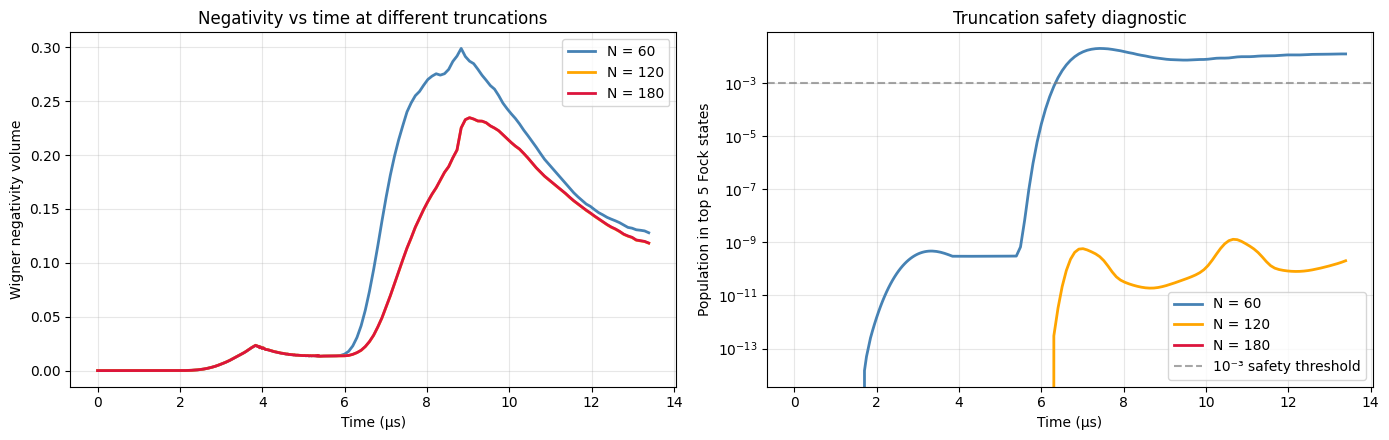


Peak negativity comparison:
  N =  60: peak = 0.29894   (rel. diff from N=180: +27.36%)
  N = 120: peak = 0.23464   (rel. diff from N=180: -0.03%)
  N = 180: peak = 0.23471   (rel. diff from N=180: +0.00%)
Building converged state at N = 120 ...
  Peak state found at index 36, neg_vol = 0.23385
  State built in 217.2 s

--- Resolution convergence (range = ±10) ---
  n =   50  (spacing = 0.4082)  →  neg_vol = 0.22878
  n =   80  (spacing = 0.2532)  →  neg_vol = 0.23764
  n =  100  (spacing = 0.2020)  →  neg_vol = 0.23257
  n =  150  (spacing = 0.1342)  →  neg_vol = 0.23460
  n =  200  (spacing = 0.1005)  →  neg_vol = 0.23399
  n =  300  (spacing = 0.0669)  →  neg_vol = 0.23381
  n =  400  (spacing = 0.0501)  →  neg_vol = 0.23379

--- Range convergence (spacing ≈ 0.08) ---
  range = ± 4  (n =  101)  →  neg_vol = 0.06396
  range = ± 6  (n =  151)  →  neg_vol = 0.13648
  range = ± 8  (n =  201)  →  neg_vol = 0.23374
  range = ±10  (n =  251)  →  neg_vol = 0.23374
  range = ±12  (n =  301)

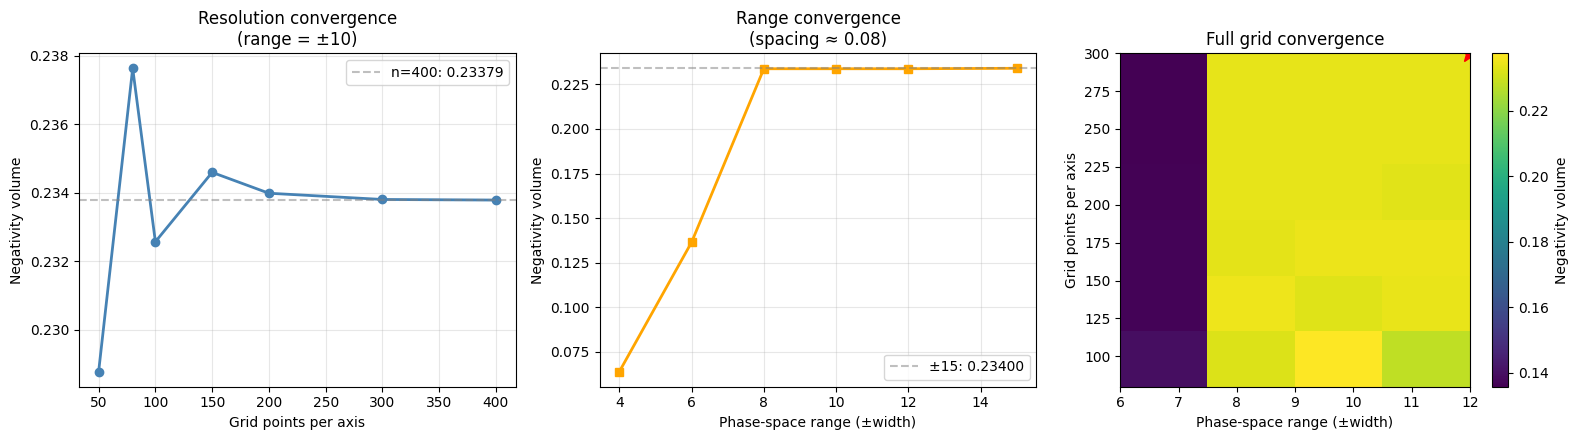


Your current grid (n=250, ±10):  neg_vol = 0.23385
Best converged grid:            neg_vol = 0.23387
Relative difference:            -0.01%
Relative difference bigger grid:  -0.063%
Relative difference finer grid:   +0.025%


In [2]:
"""
Example of convergence check for Hilbert-space truncation. This is for the Master equation.

Re-runs the optimal protocol at N = 60, 120, and 180 and compares:
  1. Negativity volume vs time
  2. Top-5 Fock populations (to verify the truncation is now safe)
  3. Wigner function at the negativity peak

"""

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import time

# ── Set the optimal protocol parameters  ─
tau1_opt = 3.84e-6     
tau2_opt = 1.55e-6
T_final  = 8e-6

# ── Physical parameters (unchanged) ──────────────────────────────────────────
omega = 2 * np.pi * 170e3
alpha = 0.5
beta  = 0.001


Gamma_qba     = 2 * np.pi * 2.54e3
Gamma_qba_dim = Gamma_qba / omega

# ── Helper: build operators for a given truncation ───────────────────────────
def build_ops(N):
    a    = qt.destroy(N)
    x    = (a + a.dag()) / np.sqrt(2)
    p    = 1j * (a.dag() - a) / np.sqrt(2)
    H_q  = 0.5 * p * p + beta  * x**4
    H_h  = 0.5 * p * p + alpha * x**2
    c_qba  = np.sqrt(Gamma_qba_dim)            * x
    return a, x, p, H_q, H_h, [c_qba]

# ── Wigner negativity (same grid for all N) ──────────────────────────────────
xvec = np.linspace(-8, 8, 120)
def neg_vol(state):
    W  = qt.wigner(state, xvec, xvec)
    dx = xvec[1] - xvec[0]
    return 0.5 * np.sum(np.abs(W) - W) * dx**2

# ── Run full 3-phase protocol for a given N ──────────────────────────────────
def run_protocol(N, n_steps_per_phase=80):
    a, x, p, H_q, H_h, c_ops = build_ops(N)
    rho_0 = qt.ket2dm(qt.basis(N, 0))

    # Phase 1: quartic for tau1
    t1 = np.linspace(0, tau1_opt * omega, n_steps_per_phase)
    r1 = qt.mesolve(H_q, rho_0, t1, c_ops,
                    options={'nsteps': 200000, 'store_states': True})

    # Phase 2: harmonic bridge for tau2
    t2 = np.linspace(0, tau2_opt * omega, n_steps_per_phase)
    r2 = qt.mesolve(H_h, r1.states[-1], t2, c_ops,
                    options={'nsteps': 200000, 'store_states': True})

    # Phase 3: quartic for T_final
    t3 = np.linspace(0, T_final * omega, n_steps_per_phase)
    r3 = qt.mesolve(H_q, r2.states[-1], t3, c_ops,
                    options={'nsteps': 200000, 'store_states': True})

    # Concatenate everything (drop duplicate boundary points)
    t_all      = np.concatenate([t1, t1[-1] + t2[1:], t1[-1] + t2[-1] + t3[1:]])
    states_all = list(r1.states) + list(r2.states[1:]) + list(r3.states[1:])
    t_us       = t_all / omega * 1e6

    # Negativity and top-Fock population diagnostics
    neg   = np.array([neg_vol(s)              for s in states_all])
    top5  = np.array([np.abs(s.diag()[-5:]).sum() for s in states_all])
    return t_us, neg, top5, states_all

# ── Run for three N values ───────────────────────────────────────────────────
N_values = [60, 120, 180]
results  = {}

for N in N_values:
    print(f"\nRunning N = {N} ...")
    t0 = time.time()
    t_us, neg, top5, states = run_protocol(N)
    dt = time.time() - t0
    print(f"  Done in {dt:.1f} s")
    print(f"  Peak negativity volume      : {neg.max():.4f}")
    print(f"  Max top-5 Fock population    : {top5.max():.2e}")
    results[N] = (t_us, neg, top5, states)

# ── Plot the comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: negativity vs time
ax = axes[0]
colors = ['steelblue', 'orange', 'crimson']
for (N, color) in zip(N_values, colors):
    t_us, neg, _, _ = results[N]
    ax.plot(t_us, neg, color=color, lw=2, label=f'N = {N}')
ax.set_xlabel('Time (μs)')
ax.set_ylabel('Wigner negativity volume')
ax.set_title('Negativity vs time at different truncations')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: top-5 Fock population vs time (log scale)
ax = axes[1]
for (N, color) in zip(N_values, colors):
    t_us, _, top5, _ = results[N]
    ax.semilogy(t_us, top5, color=color, lw=2, label=f'N = {N}')
ax.axhline(1e-3, color='gray', ls='--', alpha=0.7,
           label='10⁻³ safety threshold')
ax.set_xlabel('Time (μs)')
ax.set_ylabel('Population in top 5 Fock states')
ax.set_title('Truncation safety diagnostic')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('convergence_check.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Peak comparison ──────────────────────────────────────────────────────────
print("\n" + "="*55)
print("Peak negativity comparison:")
peaks = [results[N][1].max() for N in N_values]
ref   = peaks[-1]   # use highest N as reference
for N, peak in zip(N_values, peaks):
    rel_err = (peak - ref) / ref * 100
    print(f"  N = {N:3d}: peak = {peak:.5f}   (rel. diff from N={N_values[-1]}: {rel_err:+.2f}%)")
    

    
"""
Grid convergence check for Wigner function negativity volume.

Uses the converged N=120 state at the negativity peak and recomputes
the Wigner function on grids of varying resolution and range.

Two independent parameters:
  - range (width): how far out in phase space we compute W
  - resolution (n_points): how many grid points per axis

Both can affect the computed negativity volume.
"""

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import time

# ── Parameters (same as main simulation) ─────────────────────────────────────
omega         = 2 * np.pi * 170e3
alpha         = 0.5
beta          = 0.001
Gamma_qba     = 2 * np.pi * 2.54e3
Gamma_qba_dim = Gamma_qba / omega

# Optimal protocol parameters 
tau1_opt = 3.84*1e-6
tau2_opt = 1.55*1e-6
T_final  = 8e-6

# ── Build the converged state at N=120 ───────────────────────────────────────
N = 120
print(f"Building converged state at N = {N} ...")

a      = qt.destroy(N)
x_op   = (a + a.dag()) / np.sqrt(2)
p_op   = 1j * (a.dag() - a) / np.sqrt(2)
H_q    = 0.5 * p_op * p_op + beta  * x_op**4
H_h    = 0.5 * p_op * p_op + alpha * x_op**2
c_ops  = [
    np.sqrt(Gamma_qba_dim)            * x_op,
]
rho_0 = qt.ket2dm(qt.basis(N, 0))

n_steps = 80

# Phase 1
t0 = time.time()
t1 = np.linspace(0, tau1_opt * omega, n_steps)
r1 = qt.mesolve(H_q, rho_0, t1, c_ops,
                options={'nsteps': 200000, 'store_states': True})

# Phase 2
t2 = np.linspace(0, tau2_opt * omega, n_steps)
r2 = qt.mesolve(H_h, r1.states[-1], t2, c_ops,
                options={'nsteps': 200000, 'store_states': True})

# Phase 3
t3 = np.linspace(0, T_final * omega, n_steps)
r3 = qt.mesolve(H_q, r2.states[-1], t3, c_ops,
                options={'nsteps': 200000, 'store_states': True})

# Find the peak negativity state in phase 3
xvec_ref = np.linspace(-10, 10, 250)
def neg_vol(state, xv):
    W  = qt.wigner(state, xv, xv)
    dx = xv[1] - xv[0]
    return 0.5 * np.sum(np.abs(W) - W) * dx**2

neg_p3  = [neg_vol(s, xvec_ref) for s in r3.states]
idx_peak = np.argmax(neg_p3)
state_peak = r3.states[idx_peak]
print(f"  Peak state found at index {idx_peak}, neg_vol = {neg_p3[idx_peak]:.5f}")
print(f"  State built in {time.time() - t0:.1f} s")


# ════════════════════════════════════════════════════════════════════════════
# 1.  RESOLUTION CONVERGENCE (fixed range, increasing n_points)
# ════════════════════════════════════════════════════════════════════════════
width_fixed = 10
resolutions = [50, 80, 100, 150, 200, 300, 400]

print(f"\n--- Resolution convergence (range = ±{width_fixed}) ---")
neg_res = []
for nx in resolutions:
    xv = np.linspace(-width_fixed, width_fixed, nx)
    nv = neg_vol(state_peak, xv)
    neg_res.append(nv)
    spacing = xv[1] - xv[0]
    print(f"  n = {nx:4d}  (spacing = {spacing:.4f})  →  neg_vol = {nv:.5f}")


# ════════════════════════════════════════════════════════════════════════════
# 2.  RANGE CONVERGENCE (fixed resolution density, increasing width)
# ════════════════════════════════════════════════════════════════════════════
spacing_fixed = 0.08   # fixed spacing in phase-space units
widths = [4, 6, 8, 10, 12, 15]

print(f"\n--- Range convergence (spacing ≈ {spacing_fixed}) ---")
neg_range = []
for w in widths:
    nx = int(2 * w / spacing_fixed) + 1
    xv = np.linspace(-w, w, nx)
    nv = neg_vol(state_peak, xv)
    neg_range.append(nv)
    print(f"  range = ±{w:2d}  (n = {nx:4d})  →  neg_vol = {nv:.5f}")


# ════════════════════════════════════════════════════════════════════════════
# 3.  FULL 2D GRID SCAN (resolution × range)
# ════════════════════════════════════════════════════════════════════════════
print("\n--- Full grid scan ---")
res_scan    = [80, 100, 150, 200, 250, 300]
width_scan  = [6, 8, 10, 12]

grid_results = np.zeros((len(res_scan), len(width_scan)))
for i, nx in enumerate(res_scan):
    for j, w in enumerate(width_scan):
        xv = np.linspace(-w, w, nx)
        nv = neg_vol(state_peak, xv)
        grid_results[i, j] = nv

# Print as a table
header = "  n_pts  |  " + "  |  ".join([f"±{w}" for w in width_scan])
print(header)
print("  " + "-" * len(header))
for i, nx in enumerate(res_scan):
    row = f"  {nx:5d}  |  " + "  |  ".join([f"{grid_results[i,j]:.5f}" for j in range(len(width_scan))])
    print(row)


# ════════════════════════════════════════════════════════════════════════════
# 4.  PLOTS
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Left: resolution convergence
ax = axes[0]
ax.plot(resolutions, neg_res, 'o-', color='steelblue', lw=2)
ax.axhline(neg_res[-1], color='gray', ls='--', alpha=0.5,
           label=f'n={resolutions[-1]}: {neg_res[-1]:.5f}')
ax.set_xlabel('Grid points per axis')
ax.set_ylabel('Negativity volume')
ax.set_title(f'Resolution convergence\n(range = ±{width_fixed})')
ax.legend()
ax.grid(True, alpha=0.3)

# Middle: range convergence
ax = axes[1]
ax.plot(widths, neg_range, 's-', color='orange', lw=2)
ax.axhline(neg_range[-1], color='gray', ls='--', alpha=0.5,
           label=f'±{widths[-1]}: {neg_range[-1]:.5f}')
ax.set_xlabel('Phase-space range (±width)')
ax.set_ylabel('Negativity volume')
ax.set_title(f'Range convergence\n(spacing ≈ {spacing_fixed})')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: 2D heatmap
ax = axes[2]
im = ax.imshow(grid_results, cmap='viridis', aspect='auto',
               origin='lower',
               extent=[width_scan[0], width_scan[-1],
                       res_scan[0], res_scan[-1]])
plt.colorbar(im, ax=ax, label='Negativity volume')
ax.set_xlabel('Phase-space range (±width)')
ax.set_ylabel('Grid points per axis')
ax.set_title('Full grid convergence')

# Annotate the converged value
i_best, j_best = len(res_scan)-1, len(width_scan)-1
ax.plot(width_scan[j_best], res_scan[i_best], 'r*', ms=14)

plt.tight_layout()
plt.savefig('grid_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final summary ────────────────────────────────────────────────────────────
converged = grid_results[-1, -1]
your_current = grid_results[
    res_scan.index(250) if 250 in res_scan else 0,
    width_scan.index(10) if 10 in width_scan else 0
]
print(f"\n{'='*55}")
print(f"current grid (n=250, ±10):  neg_vol = {your_current:.5f}")
print(f"Best converged grid:            neg_vol = {converged:.5f}")
print(f"Relative difference:            {(your_current - converged)/converged * 100:+.2f}%")

print(f"Relative difference bigger grid:  "
      f"{100*(your_current/neg_range[-1]-1):+.3f}%")
print(f"Relative difference finer grid:   "
      f"{100*(your_current/neg_res[-1]-1):+.3f}%")
